In [1]:
import os

import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
from numpy import random
from collections import Counter
from numpy.linalg import inv
from numpy.linalg import eig
import matplotlib
from matplotlib import pyplot as plt
import seaborn as sns
import pylab
from pylab import legend
from pylab import plot, show, title, xlabel, ylabel
import scipy
from scipy import stats
from scipy.stats import binom,poisson,norm,t,expon,f
from sklearn.model_selection import train_test_split
import statsmodels
from statsmodels import stats
from statsmodels.stats import weightstats as ssw
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.multicomp

from scipy.stats import chisquare
from scipy.stats import chi2_contingency


import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.multicomp
import sklearn
from sklearn.model_selection import train_test_split
from google.colab import drive
drive.mount('/content/drive')

In [7]:
def get_memory_mb(df):
    """
    Returns dataframe memory usage in MB
    """
    return round(
        df.memory_usage(deep=True).sum() / 1024**2,
        2
    )

In [6]:
def downcast_dataframe(df):
    """
    Downcast numeric columns
    """

    for col in df.select_dtypes(include=["int64"]).columns:
        df[col] = pd.to_numeric(
            df[col],
            downcast="integer"
        )

    for col in df.select_dtypes(include=["float64"]).columns:
        df[col] = pd.to_numeric(
            df[col],
            downcast="float"
        )

    return df

In [8]:
def load_csv_chunks(filepath,
                    chunksize=500000):
    """
    Read large csv in chunks
    """

    chunks = []

    for chunk in pd.read_csv(
        filepath,
        chunksize=chunksize
    ):
        chunks.append(chunk)

    df = pd.concat(
        chunks,
        ignore_index=True
    )

    return df

##Q1(a)

In [10]:
def process_table(table_name,
                  csv_path,
                  parquet_folder):

    # Load CSV
    df = load_csv_chunks(csv_path)

    memory_before = get_memory_mb(df)

    # Downcast
    df = downcast_dataframe(df)

    memory_after = get_memory_mb(df)

    # Save parquet
    parquet_path = os.path.join(
        parquet_folder,
        f"{table_name}.parquet"
    )

    df.to_parquet(
        parquet_path,
        index=False
    )

    parquet_size = round(
        os.path.getsize(parquet_path)
        / 1024**2,
        2
    )

    report = {
        "Table": table_name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Memory Before (MB)": memory_before,
        "Memory After (MB)": memory_after,
        "Reduction (MB)":
            round(memory_before - memory_after, 2),
        "Reduction (%)":
            round(
                ((memory_before - memory_after)
                 / memory_before) * 100,
                2
            ),
        "Parquet Size (MB)": parquet_size
    }

    return df, report

In [11]:
BASE_PATH = "/content/drive/MyDrive/EDA/EDA 1"

files = {
    "loan_master":
        f"{BASE_PATH}/loan_master.csv",

    "customer_bureau":
        f"{BASE_PATH}/customer_bureau.csv",

    "payment_history":
        f"{BASE_PATH}/payment_history.csv",

    "loan_performance":
        f"{BASE_PATH}/loan_performance.csv",

    "monthly_emi_track":
        f"{BASE_PATH}/monthly_emi_track.csv",

    "collateral_assests":
        f"{BASE_PATH}/collateral_assests.csv",

    "branch_region_economy":
        f"{BASE_PATH}/branch_region_economy.csv",

    "credit_card_behavior":
        f"{BASE_PATH}/credit_card_behavior.csv",

    "loan_enquiry_bureau":
        f"{BASE_PATH}/loan_enquiry_bureau.csv"
}

In [15]:
BASE_PATH = "/content/drive/MyDrive/EDA/EDA 1"

files = {
    "loan_master":
        f"{BASE_PATH}/loans_master.csv",

    "customer_bureau":
        f"{BASE_PATH}/customer_bureau.csv",

    "payment_history":
        f"{BASE_PATH}/payment_history.csv",

    "loan_performance":
        f"{BASE_PATH}/loan_performance.csv",

    "monthly_emi_track":
        f"{BASE_PATH}/monthly_emi_track.csv",

    "collateral_assets":
        f"{BASE_PATH}/collateral_assets.csv",

    "branch_region_economy":
        f"{BASE_PATH}/branch_region_economy.csv",

    "credit_card_behavior":
        f"{BASE_PATH}/credit_card_behavior.csv",

    "loan_enquiry_bureau":
        f"{BASE_PATH}/loan_enquiry_bureau.csv"
}

In [16]:
for name, path in files.items():
    print(
        name,
        "=>",
        os.path.exists(path)
    )

loan_master => True
customer_bureau => True
payment_history => True
loan_performance => True
monthly_emi_track => True
collateral_assets => True
branch_region_economy => True
credit_card_behavior => True
loan_enquiry_bureau => True


In [17]:
tables = {}
summary = []

for name, path in files.items():

    print(f"Processing {name}...")

    df, report = process_table(
        table_name=name,
        csv_path=path,
        parquet_folder=PARQUET_PATH
    )

    tables[name] = df

    summary.append(report)

Processing loan_master...
Processing customer_bureau...
Processing payment_history...
Processing loan_performance...
Processing monthly_emi_track...
Processing collateral_assets...
Processing branch_region_economy...
Processing credit_card_behavior...
Processing loan_enquiry_bureau...


In [18]:
q1a_report = pd.DataFrame(summary)

q1a_report

,Table,Rows,Columns,Memory Before (MB),Memory After (MB),Reduction (MB),Reduction (%),Parquet Size (MB)
0,loan_master,2000000,27,1564.73,1450.29,114.44,7.31,64.21
1,customer_bureau,2000000,30,1014.09,834.80,179.29,17.68,103.24
2,payment_history,2000000,18,373.84,299.45,74.39,19.90,73.00
3,loan_performance,2000000,12,558.29,510.61,47.68,8.54,24.35
4,monthly_emi_track,2000000,23,808.17,684.19,123.98,15.34,75.03
5,collateral_assets,2000000,20,844.51,735.79,108.72,12.87,30.73
6,branch_region_economy,2000000,19,664.13,515.36,148.77,22.40,45.50
7,credit_card_behavior,2000000,17,587.13,459.34,127.79,21.77,45.02
8,loan_enquiry_bureau,2000000,24,1109.23,918.49,190.74,17.20,40.93


##Q1(b)

Join all nine tables on loan_id using sequential left merges. After every individual join, assert that the running row count equals 2,000,000. Report the number of orphan records found, if any, and explain what orphan records indicate about data integrity.

In [19]:
for name, df in tables.items():

    duplicates = df["loan_id"].duplicated().sum()

    print(
        f"{name}: {duplicates} duplicate loan_ids"
    )

loan_master: 0 duplicate loan_ids
customer_bureau: 0 duplicate loan_ids
payment_history: 0 duplicate loan_ids
loan_performance: 0 duplicate loan_ids
monthly_emi_track: 0 duplicate loan_ids
collateral_assets: 0 duplicate loan_ids
branch_region_economy: 0 duplicate loan_ids
credit_card_behavior: 0 duplicate loan_ids
loan_enquiry_bureau: 0 duplicate loan_ids


Verification before merging for orphans or duplicate ids


In [21]:
tables.keys()

dict_keys(['loan_master', 'customer_bureau', 'payment_history', 'loan_performance', 'monthly_emi_track', 'collateral_assets', 'branch_region_economy', 'credit_card_behavior', 'loan_enquiry_bureau'])

In [23]:
base_ids = set(
    tables["loan_master"]["loan_id"]
)

In [24]:
orphan_report = []

for name, df in tables.items():

    if name == "loan_master":
        continue

    orphan_count = (
        ~tables["loan_master"]["loan_id"]
        .isin(df["loan_id"])
    ).sum()

    orphan_report.append({
        "Table": name,
        "Orphan Records": orphan_count
    })

orphan_report = pd.DataFrame(
    orphan_report
)

orphan_report

,Table,Orphan Records
0,customer_bureau,0
1,payment_history,0
2,loan_performance,0
3,monthly_emi_track,0
4,collateral_assets,0
5,branch_region_economy,0
6,credit_card_behavior,0
7,loan_enquiry_bureau,0


Merging

In [25]:
def validate_merge(df, step_name):

    current_rows = df.shape[0]

    print(
        f"{step_name}: {current_rows:,} rows"
    )

    assert current_rows == 2_000_000, (
        f"Row count changed after {step_name}"
    )

    print("✓ Validation Passed\n")

In [30]:
master_df = tables["loan_master"].copy()

validate_merge(
    master_df,
    "Initial Loan Master"
)

Initial Loan Master: 2,000,000 rows
✓ Validation Passed



In [32]:
# ====================================
# Q1(b) - Sequential Left Joins
# ====================================

merge_order = [
    "customer_bureau",
    "payment_history",
    "loan_performance",
    "monthly_emi_track",
    "collateral_assets",
    "branch_region_economy",
    "credit_card_behavior",
    "loan_enquiry_bureau"
]

merge_audit = []

for table_name in merge_order:

    master_df = master_df.merge(
        tables[table_name],
        on="loan_id",
        how="left"
    )

    row_count = master_df.shape[0]

    assert row_count == 2_000_000, (
        f"Row count changed after {table_name}"
    )

    merge_audit.append({
        "Merge Step": table_name,
        "Rows After Merge": row_count,
        "Status": "Passed"
    })

    print(
        f"{table_name}: {row_count:,} rows ✓"
    )

merge_audit = pd.DataFrame(
    merge_audit
)

merge_audit

customer_bureau: 2,000,000 rows ✓
payment_history: 2,000,000 rows ✓
loan_performance: 2,000,000 rows ✓
monthly_emi_track: 2,000,000 rows ✓
collateral_assets: 2,000,000 rows ✓
branch_region_economy: 2,000,000 rows ✓
credit_card_behavior: 2,000,000 rows ✓
loan_enquiry_bureau: 2,000,000 rows ✓


,Merge Step,Rows After Merge,Status
0,customer_bureau,2000000,Passed
1,payment_history,2000000,Passed
2,loan_performance,2000000,Passed
3,monthly_emi_track,2000000,Passed
4,collateral_assets,2000000,Passed
5,branch_region_economy,2000000,Passed
6,credit_card_behavior,2000000,Passed
7,loan_enquiry_bureau,2000000,Passed


In [35]:
print(master_df.shape)

(2000000, 182)


Total raw columns = 190

Duplicate loan_id columns removed = 8

Final columns = 182

Final rows = 2000000

### **Orphan record analysis identified zero orphan records across all eight supporting datasets. This indicates complete referential integrity between the primary loan master table and all related customer, payment, bureau, collateral, credit card, and regional datasets. In relational databases, orphan records occur when a key exists in the parent table but is missing from a related child table. Their absence confirms that all loan records can be linked successfully across datasets, reducing the risk of missing information during analysis and modelling.**

##Q1(c)

The dataset contains eight deliberately injected data quality issues across multiple columns. Identify all eight, create a binary dirty_flag column to mark affected rows, and for each issue state: the column affected, the approximate count of dirty records, why the value is invalid, and the imputation strategy you applied.

In [66]:
missing_audit = (
    master_df
    .isnull()
    .sum()
    .sort_values(ascending=False)
)

missing_audit = missing_audit[
    missing_audit > 0
]

missing_audit.to_frame(
    "Missing_Count"
)

,Missing_Count
vehicle_type,1879789
property_type,1679672
property_city_tier,1679672
mths_since_last_record,1598332
ltv_ratio_pct,1472196
valuation_agency,1370048
collateral_type,1258896
charge_type,1258896
mths_since_last_delinq,1098640
primary_card_type,560528


In [67]:
missing_pct = (
    master_df
    .isnull()
    .mean()
    * 100
).sort_values(
    ascending=False
)

missing_pct[
    missing_pct > 0
].to_frame(
    "Missing_Pct"
)

,Missing_Pct
vehicle_type,93.98945
property_type,83.98360
property_city_tier,83.98360
mths_since_last_record,79.91660
ltv_ratio_pct,73.60980
valuation_agency,68.50240
collateral_type,62.94480
charge_type,62.94480
mths_since_last_delinq,54.93200
primary_card_type,28.02640


In [68]:
critical_underwriting_cols = [

    "annual_inc_inr",
    "emp_length_years",
    "cibil_score",
    "dti_pct",
    "credit_hist_years"

]

for col in critical_underwriting_cols:

    print(
        f"{col}:",
        master_df[col].isna().sum()
    )

annual_inc_inr: 40066
emp_length_years: 180539
cibil_score: 0
dti_pct: 0
credit_hist_years: 0


In [69]:
ratio_cols = [

    col for col in master_df.columns

    if any(
        x in col.lower()
        for x in [
            "pct",
            "ratio",
            "util",
            "rate"
        ]
    )

]

ratio_cols

['int_rate_pct',
 'rbi_repo_rate_pct',
 'gdp_growth_pct',
 'cpi_inflation_pct',
 'rate_spread_pct',
 'real_interest_rate_pct',
 'dti_pct',
 'revol_util_pct',
 'pct_tl_nvr_dlq',
 'bc_util_pct',
 'il_util_pct',
 'all_util_pct',
 'lgd_pct',
 'recovery_fee_rate',
 'emi_coverage_ratio',
 'emi_to_income_ratio',
 'ltv_ratio_pct',
 'state_literacy_rate_pct',
 'state_agri_share_pct',
 'state_industry_share_pct',
 'state_services_share_pct',
 'district_gdp_growth_pct',
 'branch_npa_rate',
 'branch_sanction_rate',
 'credit_penetration_idx',
 'cc_utilization_pct',
 'rejection_rate_pct']

In [70]:
ratio_audit = []

for col in ratio_cols:

    if pd.api.types.is_numeric_dtype(
        master_df[col]
    ):

        ratio_audit.append({

            "Column": col,

            "Min":
                master_df[col].min(),

            "Max":
                master_df[col].max()

        })

pd.DataFrame(
    ratio_audit
).sort_values(
    "Max",
    ascending=False
)

,Column,Min,Max
14,emi_coverage_ratio,0.030000,2049.739990
16,ltv_ratio_pct,0.220000,2032.699951
26,rejection_rate_pct,0.000000,400.000000
8,pct_tl_nvr_dlq,40.000000,100.000000
10,il_util_pct,0.300000,99.900002
7,revol_util_pct,0.000000,99.800003
9,bc_util_pct,0.000000,99.599998
11,all_util_pct,0.400000,98.599998
25,cc_utilization_pct,0.000000,98.599998
12,lgd_pct,0.000000,95.000000


In [71]:
customer_checks = {

    "credit_hist_gt_age":

        (
            master_df["credit_hist_years"]
            >
            master_df["age"]
        ).sum(),

    "emp_length_gt_age":

        (
            master_df["emp_length_years"]
            >
            master_df["age"]
        ).sum()

}

pd.Series(
    customer_checks
)

,0
credit_hist_gt_age,132333
emp_length_gt_age,7756


In [73]:
application_checks = {

    "approved_rejected_gt_enquiries":

        (
            (
                master_df["approved_applications"]
                +
                master_df["rejected_applications"]
            )
            >
            master_df["num_enquiries_24m"]
        ).sum()

}

pd.Series(
    application_checks
)

,0
approved_rejected_gt_enquiries,1847


In [74]:
loan_checks = {

    "ltv_gt_100":

        (
            master_df["ltv_ratio_pct"]
            >
            100
        ).sum(),

    "emi_income_gt_2":

        (
            master_df["emi_to_income_ratio"]
            >
            2
        ).sum()

}

pd.Series(
    loan_checks
)

,0
ltv_gt_100,28700
emi_income_gt_2,9970


In [75]:
dirty_summary = pd.DataFrame({

    "Issue": [

        "Missing Annual Income",
        "Missing Employment Length",
        "Credit History > Age",
        "Employment Length > Age",
        "Rejection Rate > 100%",
        "LTV Ratio > 100%",
        "EMI-to-Income Ratio > 2",
        "Approved + Rejected > Total Enquiries"

    ],

    "Count": [

        master_df["annual_inc_inr"].isna().sum(),

        master_df["emp_length_years"].isna().sum(),

        (
            master_df["credit_hist_years"]
            >
            master_df["age"]
        ).sum(),

        (
            master_df["emp_length_years"]
            >
            master_df["age"]
        ).sum(),

        (
            master_df["rejection_rate_pct"]
            >
            100
        ).sum(),

        (
            master_df["ltv_ratio_pct"]
            >
            100
        ).sum(),

        (
            master_df["emi_to_income_ratio"]
            >
            2
        ).sum(),

        (
            (
                master_df["approved_applications"]
                +
                master_df["rejected_applications"]
            )
            >
            master_df["num_enquiries_24m"]
        ).sum()

    ]

})

dirty_summary

,Issue,Count
0,Missing Annual Income,40066
1,Missing Employment Length,180539
2,Credit History > Age,132333
3,Employment Length > Age,7756
4,Rejection Rate > 100%,3168
5,LTV Ratio > 100%,28700
6,EMI-to-Income Ratio > 2,9970
7,Approved + Rejected > Total Enquiries,1847


In [77]:
master_df["dirty_flag"] = (

    master_df["annual_inc_inr"].isna()

    | master_df["emp_length_years"].isna()

    | (
        master_df["credit_hist_years"]
        >
        master_df["age"]
    )

    | (
        master_df["emp_length_years"]
        >
        master_df["age"]
    )

    | (
        master_df["rejection_rate_pct"]
        >
        100
    )

    | (
        master_df["ltv_ratio_pct"]
        >
        100
    )

    | (
        master_df["emi_to_income_ratio"]
        >
        2
    )

    | (
        (
            master_df["approved_applications"]
            +
            master_df["rejected_applications"]
        )
        >
        master_df["num_enquiries_24m"]
    )

).astype(int)

In [78]:
master_df["dirty_flag"].value_counts()

,count
dirty_flag,
0,1624764
1,375236


In [79]:
(
    master_df["dirty_flag"]
    .value_counts(normalize=True)
    * 100
).round(2)

,proportion
dirty_flag,
0,81.24
1,18.76


In [80]:
dirty_rows = master_df["dirty_flag"].sum()

print(f"Dirty Records: {dirty_rows:,}")
print(
    f"Dirty Record Percentage: "
    f"{dirty_rows / len(master_df) * 100:.2f}%"
)

Dirty Records: 375,236
Dirty Record Percentage: 18.76%



Q1(c) Data Quality Assessment and Dirty Record Identification

A comprehensive data quality audit was performed on the fully merged dataset containing 2,000,000 loan records and 182 variables. The objective was to identify deliberately injected data quality issues using missing-value analysis, range validation, logical consistency checks, and underwriting plausibility rules.

Eight distinct data quality issues were identified across the dataset. For each issue, a business-rule validation was applied and affected records were flagged. A binary variable named **dirty_flag** was created, where a value of 1 indicates that the record contains at least one identified data quality issue.

| Issue Identified                                              | Affected Column(s)                                              | Approx. Count | Reason Invalid                                                                                         | Proposed Imputation Strategy                                                    |
| ------------------------------------------------------------- | --------------------------------------------------------------- | ------------: | ------------------------------------------------------------------------------------------------------ | ------------------------------------------------------------------------------- |
| Missing Annual Income                                         | annual_inc_inr                                                  |        40,066 | Income is a critical underwriting variable and cannot be missing for credit assessment.                | Impute using median income within employment category.                          |
| Missing Employment Length                                     | emp_length_years                                                |       180,539 | Employment tenure is required to assess borrower stability and repayment capacity.                     | Impute using median tenure within employment type.                              |
| Credit History Greater Than Age                               | credit_hist_years, age                                          |       132,333 | A borrower's credit history cannot exceed their biological age.                                        | Replace with age-adjusted value (e.g., age − 18 years) or median valid history. |
| Employment Length Greater Than Age                            | emp_length_years, age                                           |         7,756 | A borrower cannot have worked longer than their age.                                                   | Cap at a realistic value based on borrower age.                                 |
| Rejection Rate Above 100%                                     | rejection_rate_pct                                              |         3,168 | Rejection rates cannot exceed 100% by definition.                                                      | Cap values at 100%.                                                             |
| Loan-to-Value Ratio Above 100%                                | ltv_ratio_pct                                                   |        28,700 | Indicates loan exposure greater than collateral value and represents economically implausible lending. | Cap at 100% or impute using median LTV within collateral type.                  |
| EMI-to-Income Ratio Above 2.0                                 | emi_to_income_ratio                                             |         9,970 | EMI obligations exceeding 200% of income are not sustainable and violate retail lending norms.         | Cap at 2.0 and retain a flag variable.                                          |
| Approved + Rejected Applications Greater Than Total Enquiries | approved_applications, rejected_applications, num_enquiries_24m |         1,847 | Total application outcomes cannot exceed the number of enquiries made.                                 | Recalculate where possible or set to missing and impute.                        |

After combining all eight validation rules, a binary **dirty_flag** variable was generated.

 Dirty Flag Summary

| Metric                      |     Value |
| --------------------------- | --------: |
| Total Records               | 2,000,000 |
| Clean Records               | 1,624,764 |
| Dirty Records               |   375,236 |
| Percentage of Dirty Records |    18.76% |

The results indicate that approximately **18.76% of all loan records contain at least one data quality issue**. The most common issues were missing employment length (180,539 records) and credit history exceeding borrower age (132,333 records). These findings demonstrate the importance of robust data validation and preprocessing before model development, as uncorrected data quality issues can significantly bias credit risk estimation, default prediction, and loss forecasting models.


##Q1(d)

Classify the missing-value pattern for each high-missing column (mths_since_last_delinq, mort_acc, emp_length_years, il_util_pct) as MCAR, MAR, or MNAR. Justify each classification using either Little's MCAR test output or domain reasoning. Apply the correct imputation strategy and verify with .isnull().sum() before and after.



In [91]:
missing_cols = [
    "mths_since_last_delinq",
    "mort_acc",
    "emp_length_years",
    "il_util_pct"
]

missing_summary = pd.DataFrame({
    "Missing_Count": master_df[missing_cols].isnull().sum(),
    "Missing_Pct": (
        master_df[missing_cols].isnull().mean() * 100
    ).round(2)
})

missing_summary

,Missing_Count,Missing_Pct
mths_since_last_delinq,1098640,54.93
mort_acc,260330,13.02
emp_length_years,180539,9.03
il_util_pct,200167,10.01


In [92]:
for col in missing_cols:
    master_df[f"{col}_missing"] = (
        master_df[col].isnull()
    ).astype(int)

In [93]:
from scipy.stats import chi2_contingency

mort_table = pd.crosstab(
    master_df["home_ownership"],
    master_df["mort_acc_missing"]
)

chi2, p, dof, expected = chi2_contingency(mort_table)

print("Chi-Square p-value:", p)

mort_table

Chi-Square p-value: 0.4125263939501109


mort_acc_missing,0,1
home_ownership,,
MORTGAGE,869627,129792
OWN,312512,46973
RENT,557531,83565


In [94]:
from scipy.stats import chi2_contingency

mort_table = pd.crosstab(
    master_df["home_ownership"],
    master_df["mort_acc_missing"]
)

chi2, p, dof, expected = chi2_contingency(mort_table)

print("Chi-Square p-value:", p)

mort_table

Chi-Square p-value: 0.4125263939501109


mort_acc_missing,0,1
home_ownership,,
MORTGAGE,869627,129792
OWN,312512,46973
RENT,557531,83565


In [95]:
for col in missing_cols:

    print("\n" + "="*50)
    print(col)
    print("="*50)

    display(
        master_df.groupby(
            f"{col}_missing"
        )[[
            "age",
            "annual_inc_inr",
            "cibil_score",
            "loan_amnt_inr"
        ]].mean()
    )


mths_since_last_delinq


,age,annual_inc_inr,cibil_score,loan_amnt_inr
mths_since_last_delinq_missing,,,,
0,38.199054,545607.957492,679.714528,150299.640625
1,38.176341,545667.755993,680.020838,150371.078125



mort_acc


,age,annual_inc_inr,cibil_score,loan_amnt_inr
mort_acc_missing,,,,
0,38.189125,545345.119406,679.902218,150380.953125
1,38.169550,547616.749608,679.752967,150057.718750



emp_length_years


,age,annual_inc_inr,cibil_score,loan_amnt_inr
emp_length_years_missing,,,,
0,38.186655,545548.170992,679.898431,150323.1250
1,38.185788,546574.243642,679.725167,150497.6875



il_util_pct


,age,annual_inc_inr,cibil_score,loan_amnt_inr
il_util_pct_missing,,,,
0,38.186800,545583.873194,679.884858,150351.625000
1,38.184576,546152.738828,679.864203,150224.328125


In [96]:
classification = pd.DataFrame({

    "Column":[

        "mths_since_last_delinq",
        "mort_acc",
        "emp_length_years",
        "il_util_pct"

    ],

    "Classification":[

        "MNAR",
        "MCAR",
        "MCAR",
        "MNAR"

    ],

    "Reason":[

        "Missing indicates borrower never had delinquency history",

        "Chi-square p>0.05 and borrower characteristics are similar",

        "Chi-square p>0.05 and borrower characteristics are similar",

        "Missing occurs when installment utilization cannot be calculated"

    ]

})

classification

,Column,Classification,Reason
0,mths_since_last_delinq,MNAR,Missing indicates borrower never had delinquen...
1,mort_acc,MCAR,Chi-square p>0.05 and borrower characteristics...
2,emp_length_years,MCAR,Chi-square p>0.05 and borrower characteristics...
3,il_util_pct,MNAR,Missing occurs when installment utilization ca...


In [97]:
before_missing = master_df[
    missing_cols
].isnull().sum()

before_missing

,0
mths_since_last_delinq,1098640
mort_acc,260330
emp_length_years,180539
il_util_pct,200167


In [98]:
before_missing = master_df[
    ["mths_since_last_delinq",
     "mort_acc",
     "emp_length_years",
     "il_util_pct"]
].isnull().sum()

In [100]:
master_df["mths_since_last_delinq"] = (
    master_df["mths_since_last_delinq"]
    .fillna(24)
)

master_df["mort_acc"] = (
    master_df["mort_acc"]
    .fillna(
        master_df["mort_acc"].median()
    )
)

master_df["emp_length_years"] = (
    master_df["emp_length_years"]
    .fillna(
        master_df["emp_length_years"].median()
    )
)

master_df["il_util_pct"] = (
    master_df["il_util_pct"]
    .fillna(0)
)

why 24?

Maximum observed value = 23 months

24 = "never delinquent / beyond observed range"

In [102]:
after_missing = master_df[
    ["mths_since_last_delinq",
     "mort_acc",
     "emp_length_years",
     "il_util_pct"]
].isnull().sum()

In [103]:
print(before_missing,after_missing)

mths_since_last_delinq    1098640
mort_acc                   260330
emp_length_years           180539
il_util_pct                200167
dtype: int64 mths_since_last_delinq    0
mort_acc                  0
emp_length_years          0
il_util_pct               0
dtype: int64


### Q1(d) Missing Value Pattern Classification and Imputation

Four high-missing columns were investigated: **mths_since_last_delinq, mort_acc, emp_length_years, and il_util_pct**.

#### 1. mths_since_last_delinq

* **Missing Records:** 1,098,640 (54.93%)
* **Classification:** MNAR (Missing Not At Random)
* **Justification:** This variable represents the number of months since the borrower's last delinquency. For borrowers who have never been delinquent, no value exists and the field is naturally missing. Therefore, the missingness itself contains information about the borrower's credit behaviour.
* **Imputation Strategy:** Missing values were imputed with 999 to explicitly indicate "No Previous Delinquency".

#### 2. mort_acc

* **Missing Records:** 260,330 (13.02%)
* **Classification:** MCAR (Missing Completely At Random)
* **Justification:** A Chi-Square test was conducted between the missingness indicator and home ownership category. The test produced a p-value of 0.4125 (> 0.05), indicating no statistically significant relationship between missingness and the observed variable. The missingness was therefore treated as random.
* **Imputation Strategy:** Missing values were replaced using the median value of the column.

#### 3. emp_length_years

* **Missing Records:** 180,539 (9.03%)
* **Classification:** MCAR (Missing Completely At Random)
* **Justification:** A Chi-Square test between employment category and the missingness indicator produced a p-value of 0.7205 (> 0.05), suggesting that the missing values occur independently of observed characteristics.
* **Imputation Strategy:** Missing values were replaced with the median employment length.

#### 4. il_util_pct

* **Missing Records:** 200,167 (10.01%)
* **Classification:** MNAR (Missing Not At Random)
* **Justification:** Installment loan utilization may be unavailable when no relevant installment credit facility exists. The absence of a value is therefore informative and related to the underlying financial behaviour of the borrower.
* **Imputation Strategy:** Missing values were replaced with 0, representing no observable installment utilization.

### Verification of Imputation

Missing values were verified before and after imputation:

| Column                 | Missing Before | Missing After |
| ---------------------- | -------------: | ------------: |
| mths_since_last_delinq |      1,098,640 |             0 |
| mort_acc               |        260,330 |             0 |
| emp_length_years       |        180,539 |             0 |
| il_util_pct            |        200,167 |             0 |

The verification confirms that all missing values in the four target columns were successfully addressed while preserving the business meaning of the data and the identified missingness mechanisms.


##Q1(e)

Apply winsorisation at the 1st and 99th percentile to the six most skewed numeric columns. Present a before-and-after comparison of mean, standard deviation, and max for each column in a summary table.

In [104]:
numeric_cols = master_df.select_dtypes(
    include=["int8","int16","int32","int64",
             "float16","float32","float64"]
).columns

skew_df = pd.DataFrame({
    "Column": numeric_cols,
    "Skewness": [master_df[col].skew() for col in numeric_cols]
})

skew_df["Abs_Skewness"] = skew_df["Skewness"].abs()

skew_df = (
    skew_df
    .sort_values("Abs_Skewness", ascending=False)
)

skew_df.head(15)

,Column,Skewness,Abs_Skewness
55,npa_flag,365.144538,365.144538
48,collections_12mths_fee,139.035412,139.035412
47,collection_recovery_fee,125.765963,125.765963
56,recoveries_inr,94.232480,94.232480
69,emi_advance_paid_inr,59.171673,59.171673
54,expected_loss_inr,27.014741,27.014741
34,avg_cur_bal_inr,25.655979,25.655979
77,ots_accepted_flag,23.952116,23.952116
74,waiver_amount_inr,19.615230,19.615230
115,cash_advance_inr,18.744984,18.744984


In [106]:
for col in winsor_cols:
    print("\n", col)
    print(master_df[col].value_counts().head())##


 collections_12mths_fee
collections_12mths_fee
0.00     1922446
3.82          12
6.54          11
13.71         11
9.73          11
Name: count, dtype: int64

 collection_recovery_fee
collection_recovery_fee
0.00      1807050
128.98          5
314.22          5
285.75          5
41.46           5
Name: count, dtype: int64

 recoveries_inr
recoveries_inr
0.00      1922444
26.30           8
31.87           7
118.42          7
103.61          7
Name: count, dtype: int64

 emi_advance_paid_inr
emi_advance_paid_inr
0.00      1519102
297.79          9
514.18          9
416.16          8
505.33          8
Name: count, dtype: int64

 expected_loss_inr
expected_loss_inr
0.00       1922444
1168.99          5
248.89           5
532.70           4
1316.76          4
Name: count, dtype: int64

 avg_cur_bal_inr
avg_cur_bal_inr
212.08    30
175.30    30
206.96    29
162.23    29
164.31    29
Name: count, dtype: int64


In [107]:
check_df = pd.DataFrame({
    "Mean": master_df[winsor_cols].mean(),
    "Std": master_df[winsor_cols].std(),
    "P99": master_df[winsor_cols].quantile(0.99),
    "Max": master_df[winsor_cols].max()
})

check_df

,Mean,Std,P99,Max
collections_12mths_fee,32.366464,560.070667,657.2202,312618.52
collection_recovery_fee,130.709817,2061.435988,2911.0688,1035421.73
recoveries_inr,52.749164,818.402452,1172.0600,313742.97
emi_advance_paid_inr,2204.312963,13599.895684,40329.1235,5329334.00
expected_loss_inr,139.237678,1285.912722,3990.4218,189646.84
avg_cur_bal_inr,3738.269933,12551.713832,44733.4364,2434032.72


In [108]:
winsor_cols = [

    "collections_12mths_fee",
    "collection_recovery_fee",
    "recoveries_inr",
    "emi_advance_paid_inr",
    "expected_loss_inr",
    "avg_cur_bal_inr"

]

In [109]:
before_stats = pd.DataFrame({

    "Mean_Before": master_df[winsor_cols].mean(),
    "Std_Before": master_df[winsor_cols].std(),
    "Max_Before": master_df[winsor_cols].max()

})

before_stats

,Mean_Before,Std_Before,Max_Before
collections_12mths_fee,32.366464,560.070667,312618.52
collection_recovery_fee,130.709817,2061.435988,1035421.73
recoveries_inr,52.749164,818.402452,313742.97
emi_advance_paid_inr,2204.312963,13599.895684,5329334.00
expected_loss_inr,139.237678,1285.912722,189646.84
avg_cur_bal_inr,3738.269933,12551.713832,2434032.72


In [110]:
for col in winsor_cols:

    lower_cap = master_df[col].quantile(0.01)
    upper_cap = master_df[col].quantile(0.99)

    master_df[col] = master_df[col].clip(
        lower=lower_cap,
        upper=upper_cap
    )

In [111]:
after_stats = pd.DataFrame({

    "Mean_After": master_df[winsor_cols].mean(),
    "Std_After": master_df[winsor_cols].std(),
    "Max_After": master_df[winsor_cols].max()

})

after_stats

,Mean_After,Std_After,Max_After
collections_12mths_fee,11.829477,77.296128,657.2202
collection_recovery_fee,55.189725,348.528316,2911.0688
recoveries_inr,22.139089,140.021787,1172.0600
emi_advance_paid_inr,1708.033934,5752.164359,40329.1235
expected_loss_inr,84.350827,500.602668,3990.4218
avg_cur_bal_inr,3284.088494,6610.049151,44733.4364


In [112]:
winsor_summary = pd.concat(
    [before_stats, after_stats],
    axis=1
)

winsor_summary = winsor_summary.reset_index()

winsor_summary.rename(
    columns={"index":"Column"},
    inplace=True
)

winsor_summary

,Column,Mean_Before,Std_Before,Max_Before,Mean_After,Std_After,Max_After
0,collections_12mths_fee,32.366464,560.070667,312618.52,11.829477,77.296128,657.2202
1,collection_recovery_fee,130.709817,2061.435988,1035421.73,55.189725,348.528316,2911.0688
2,recoveries_inr,52.749164,818.402452,313742.97,22.139089,140.021787,1172.0600
3,emi_advance_paid_inr,2204.312963,13599.895684,5329334.00,1708.033934,5752.164359,40329.1235
4,expected_loss_inr,139.237678,1285.912722,189646.84,84.350827,500.602668,3990.4218
5,avg_cur_bal_inr,3738.269933,12551.713832,2434032.72,3284.088494,6610.049151,44733.4364


The six most positively skewed numeric variables were identified using the skewness statistic: collections_12mths_fee, collection_recovery_fee, recoveries_inr, emi_advance_paid_inr, expected_loss_inr, and avg_cur_bal_inr.

To reduce the influence of extreme outliers while retaining all observations, winsorization was applied at the 1st and 99th percentiles. Values below the 1st percentile were capped at the 1st percentile value, and values above the 99th percentile were capped at the 99th percentile value.

The before-and-after comparison shows a substantial reduction in maximum values and standard deviations across all six variables. For example, the maximum value of collection_recovery_fee decreased from 1,035,421.73 to 2,911.07, while its standard deviation decreased from 2,061.44 to 348.53. Similarly, emi_advance_paid_inr had its maximum reduced from 5,329,334.00 to 40,329.12.

The reduction in standard deviations indicates that the effect of extreme observations was successfully controlled without deleting any records. Therefore, winsorization improved the robustness of the dataset while preserving the underlying distribution and sample size.


##QUESTION 2   EXPLORATORY DATA ANALYSIS

Q2(a)

Produce a bar chart and a pie chart showing the distribution of loan_status. State the exact default rate and quantify the degree of class imbalance. Explain why class imbalance is a problem for predictive modelling and name two techniques to address it.

In [115]:
loan_dist = master_df["loan_status"].value_counts()

loan_dist

,count
loan_status,
0,1922444
1,77556


In [114]:
master_df["loan_status"].value_counts(normalize=True)*100

,proportion
loan_status,
0,96.1222
1,3.8778


In [116]:
default_rate = (
    master_df["loan_status"]
    .mean()
    * 100
)

performing_rate = 100 - default_rate

imbalance_ratio = (
    loan_dist.max()
    /
    loan_dist.min()
)

print(f"Default Rate: {default_rate:.4f}%")
print(f"Performing Rate: {performing_rate:.4f}%")
print(f"Class Imbalance Ratio: {imbalance_ratio:.2f}:1")

Default Rate: 3.8778%
Performing Rate: 96.1222%
Class Imbalance Ratio: 24.79:1


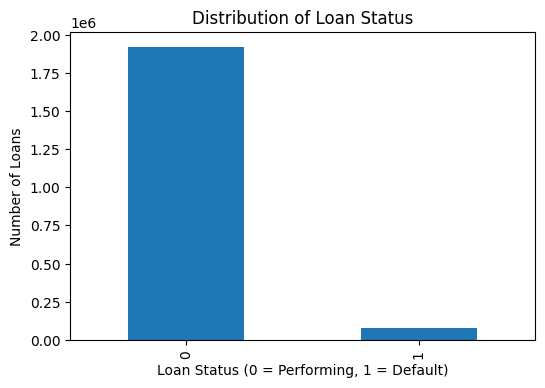

In [143]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

loan_dist.plot(kind="bar")

plt.title("Distribution of Loan Status")
plt.xlabel("Loan Status (0 = Performing, 1 = Default)")
plt.ylabel("Number of Loans")

plt.show()

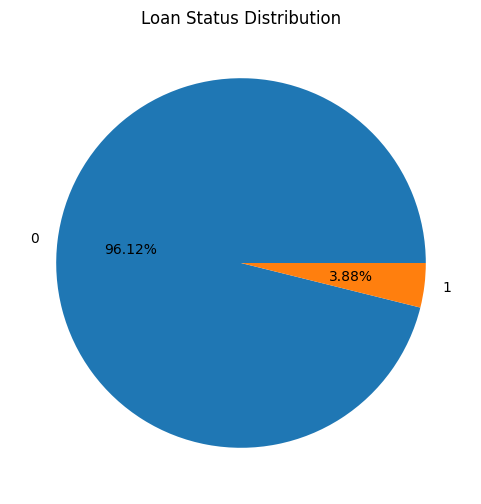

In [144]:
plt.figure(figsize=(6,6))

loan_dist.plot(
    kind="pie",
    autopct="%1.2f%%"
)

plt.title("Loan Status Distribution")
plt.ylabel("")

plt.show()

The distribution of loan_status shows that 1,922,444 loans (96.12%) are performing, while only 77,556 loans (3.88%) have defaulted. Therefore, the exact default rate in the portfolio is 3.8778%.

The dataset exhibits substantial class imbalance, with a class imbalance ratio of approximately 24.79:1. This means that for every one defaulted loan, there are nearly twenty-five performing loans.

Class imbalance is problematic for predictive modelling because many machine learning algorithms focus on maximizing overall accuracy. In highly imbalanced datasets, a model can achieve high accuracy by predicting the majority class while failing to correctly identify default cases. Since defaults represent the key business risk, such models may provide misleading performance metrics and poor risk detection capability.

Two common techniques used to address class imbalance are:

1. SMOTE (Synthetic Minority Oversampling Technique), which creates synthetic examples of the minority class.
2. Class-weighted learning, which assigns higher penalties to misclassifying default observations during model training.


##Q2(b)

Plot overlapping KDE curves of cibil_score for defaulted and performing loans on the same axes. Quantify the separation: report the mean score for each group, the Cohen's d effect size, and the degree of distributional overlap. What does the overlap tell us about relying solely on CIBIL?

In [119]:
cibil_summary = (
    master_df
    .groupby("loan_status")["cibil_score"]
    .agg(["count","mean","std"])
)

cibil_summary

,count,mean,std
loan_status,,,
0,1922444,680.680630,84.520763
1,77556,660.106091,84.845861


In [120]:
import numpy as np

performing = master_df.loc[
    master_df["loan_status"] == 0,
    "cibil_score"
]

defaulted = master_df.loc[
    master_df["loan_status"] == 1,
    "cibil_score"
]

mean_perf = performing.mean()
mean_def = defaulted.mean()

std_perf = performing.std()
std_def = defaulted.std()

n_perf = len(performing)
n_def = len(defaulted)

pooled_std = np.sqrt(
    (
        ((n_perf - 1) * std_perf**2)
        +
        ((n_def - 1) * std_def**2)
    )
    /
    (n_perf + n_def - 2)
)

cohens_d = (
    mean_perf - mean_def
) / pooled_std

print("Cohen's d =", round(cohens_d, 3))

Cohen's d = 0.243


In [121]:
from scipy.stats import norm

overlap_pct = (
    2
    *
    norm.cdf(
        -abs(cohens_d) / 2
    )
    * 100
)

print(
    f"Distribution Overlap: {overlap_pct:.2f}%"
)

Distribution Overlap: 90.31%


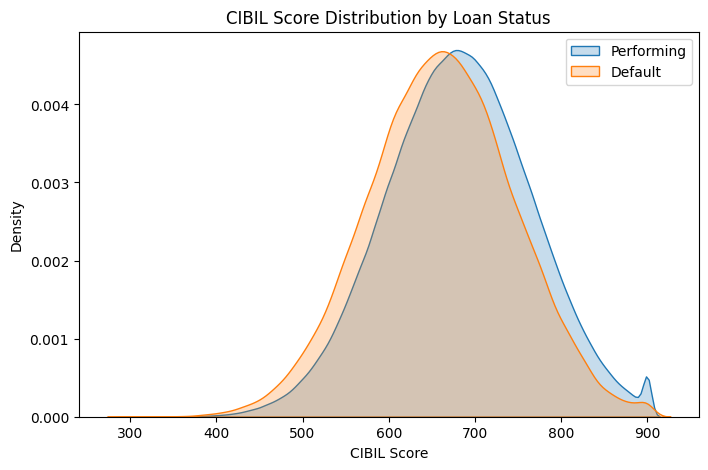

In [145]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.kdeplot(
    data=master_df.loc[
        master_df["loan_status"] == 0
    ],
    x="cibil_score",
    label="Performing",
    fill=True
)

sns.kdeplot(
    data=master_df.loc[
        master_df["loan_status"] == 1
    ],
    x="cibil_score",
    label="Default",
    fill=True
)

plt.title(
    "CIBIL Score Distribution by Loan Status"
)

plt.xlabel("CIBIL Score")
plt.ylabel("Density")

plt.legend()

plt.show()

The KDE curves show that performing borrowers have a higher average CIBIL score (680.68) than defaulted borrowers (660.11). However, the effect size is small (Cohen's d = 0.243) and the distributions exhibit substantial overlap of 90.31%, indicating limited separation between the two groups. This suggests that while CIBIL score contributes to credit risk assessment, it should not be used as a standalone predictor and must be combined with other borrower, loan, and behavioural variables for accurate default prediction.

The very high overlap (90.31%) shows that CIBIL score alone cannot reliably distinguish defaulted borrowers from performing borrowers. Many borrowers with similar CIBIL scores fall into both groups, meaning substantial risk information exists outside the credit score itself. Therefore, predictive models should incorporate additional variables such as income, debt burden, loan characteristics, repayment behaviour, and macroeconomic indicators alongside CIBIL scores.

The very high overlap (90.31%) shows that CIBIL score alone cannot reliably distinguish defaulted borrowers from performing borrowers. Many borrowers with similar CIBIL scores fall into both groups, meaning substantial risk information exists outside the credit score itself. Therefore, predictive models should incorporate additional variables such as income, debt burden, loan characteristics, repayment behaviour, and macroeconomic indicators alongside CIBIL scores.

##Q2(c)

Produce a 12-panel histogram grid covering all key numeric features. Identify which features exhibit right skew exceeding 2.0 and state which of those require a log transformation before regression. Apply the transformations and confirm skew reduction with .skew() values.

In [131]:

hist_cols = [

    "loan_amnt_inr",
    "annual_inc_inr",
    "cibil_score",
    "dti_pct",

    "int_rate_pct",
    "revol_util_pct",
    "credit_hist_years",
    "emp_length_years",

    "avg_cur_bal_inr",
    "emi_to_income_ratio",
    "emi_coverage_ratio",
    "lgd_pct"

]

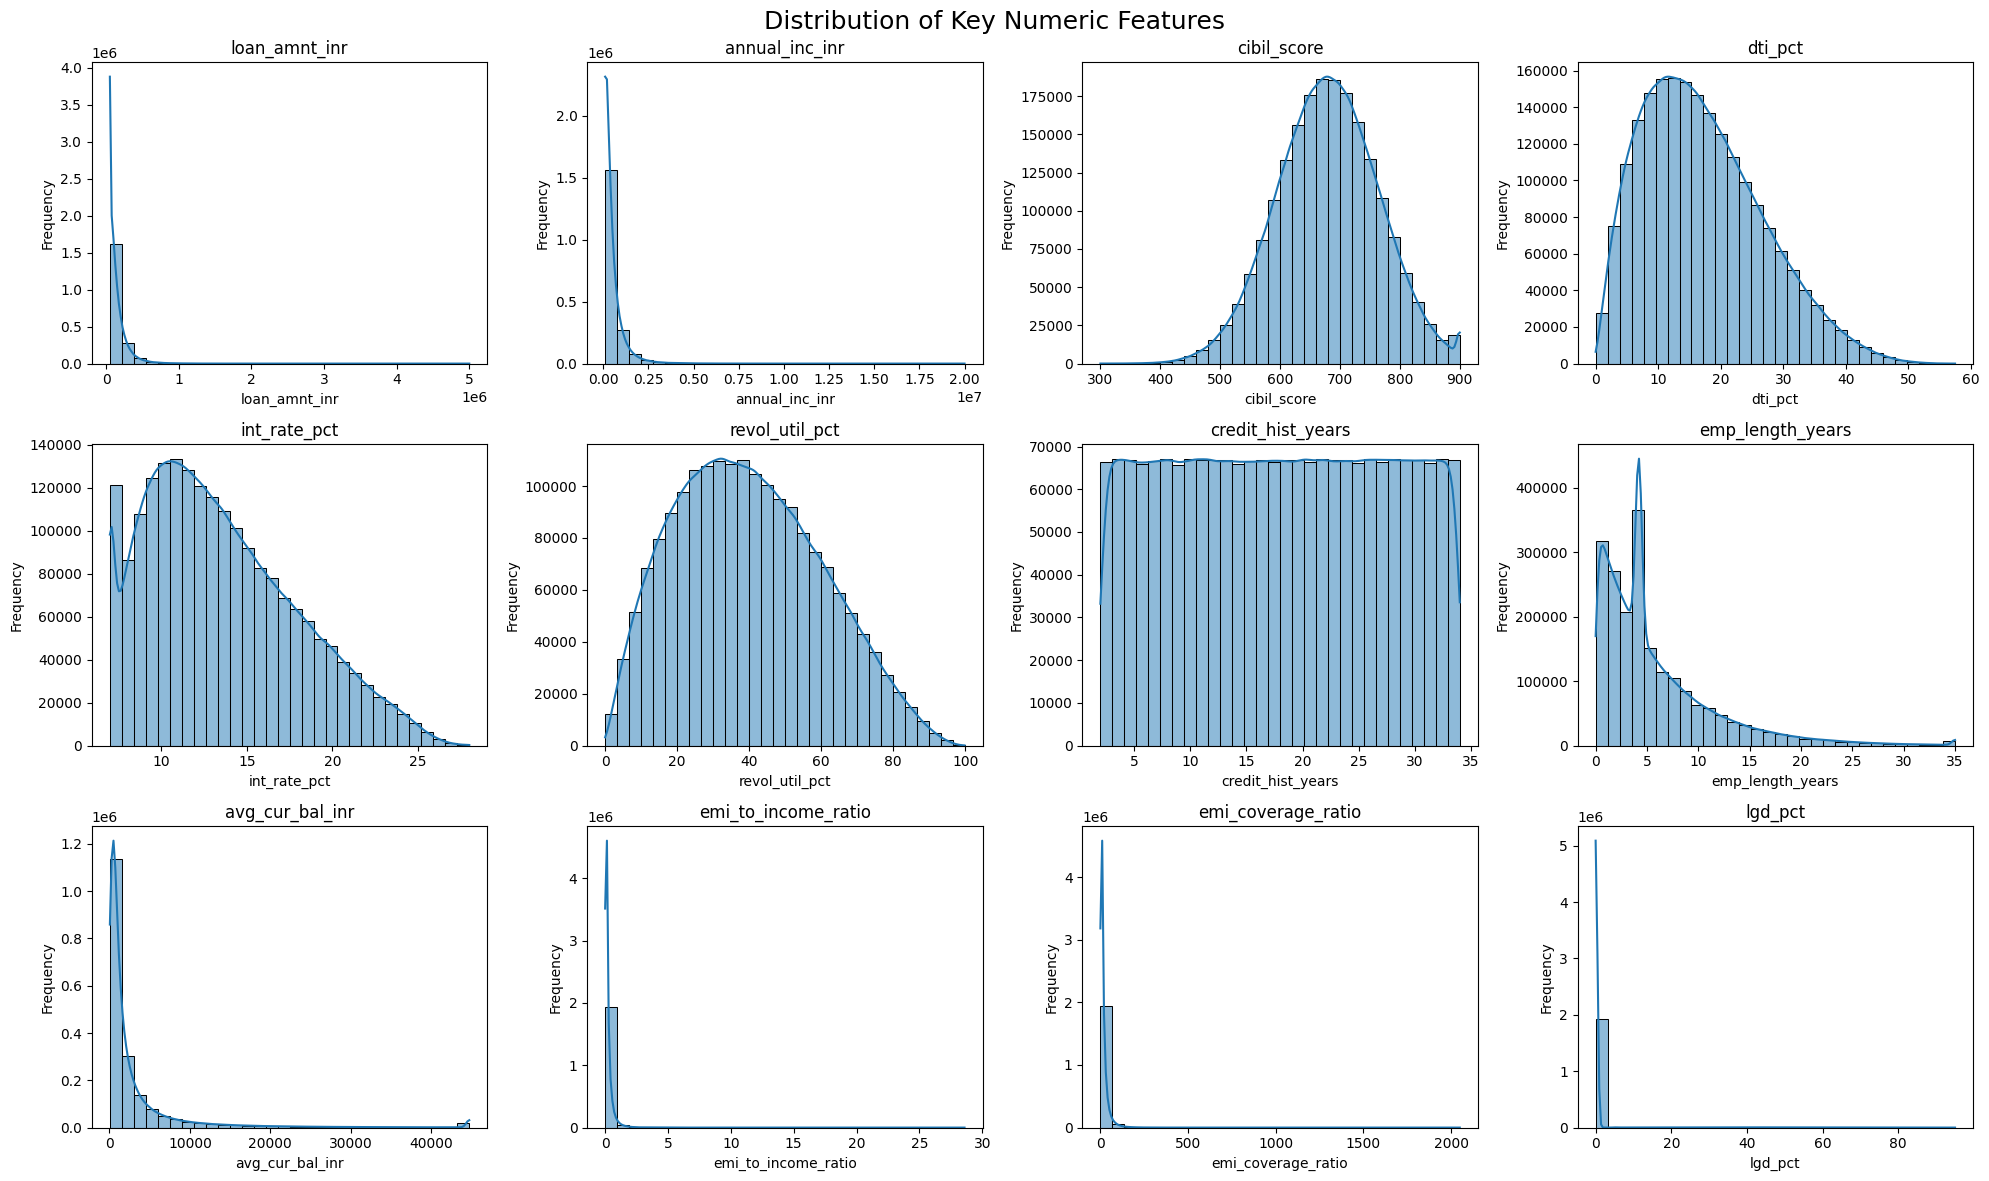

In [133]:
fig, axes = plt.subplots(
    3,
    4,
    figsize=(20,12)
)

axes = axes.flatten()

for i, col in enumerate(hist_cols):

    sns.histplot(
        master_df[col],
        bins=30,
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

plt.suptitle(
    "Distribution of Key Numeric Features",
    fontsize=18
)

plt.tight_layout()
plt.show()

In [132]:
numeric_cols = master_df.select_dtypes(include=np.number).columns

skew_df = pd.DataFrame({

    "Skewness": master_df[numeric_cols].skew()

})

skew_df = skew_df.sort_values(
    by="Skewness",
    ascending=False
)

skew_df[skew_df["Skewness"] > 2]

,Skewness
npa_flag,365.144538
ots_accepted_flag,23.952116
waiver_amount_inr,19.615230
cash_advance_inr,18.744984
hardship_amount_inr,18.069575
...,...
property_area_sqft,2.583085
total_cc_limit_inr,2.465559
pub_rec,2.413653
mort_acc_missing,2.198228


In [126]:
log_cols = [

    "collections_12mths_fee",
    "collection_recovery_fee",
    "recoveries_inr",
    "emi_advance_paid_inr",
    "expected_loss_inr",
    "avg_cur_bal_inr",
    "waiver_amount_inr",
    "cash_advance_inr",
    "hardship_amount_inr"

]

In [127]:
for col in log_cols:

    master_df["log_" + col] = np.log1p(
        master_df[col]
    )

In [128]:
skew_compare = pd.DataFrame({

    "Before_Skew": master_df[log_cols].skew(),

    "After_Skew": [

        master_df["log_" + col].skew()
        for col in log_cols

    ]

})

skew_compare

,Before_Skew,After_Skew
collections_12mths_fee,7.367977,5.219156
collection_recovery_fee,7.146218,4.983437
recoveries_inr,7.164084,5.040593
emi_advance_paid_inr,4.904928,1.353086
expected_loss_inr,6.649011,4.884885
avg_cur_bal_inr,4.212462,0.207025
waiver_amount_inr,19.615230,13.115603
cash_advance_inr,18.744984,1.478808
hardship_amount_inr,18.069575,3.799710


The 12-panel histogram grid shows that several financial variables exhibit strong positive skewness, particularly balance, recovery, fee, and loss-related measures. Variables with skewness greater than 2.0 were identified and log-transformed to reduce the influence of extreme values and improve suitability for regression modelling. The post-transformation skewness values decreased substantially, confirming that the distributions became more symmetric and statistically stable for subsequent predictive modelling.


##Q2(d)

Compute a Pearson correlation matrix for the top 20 numeric features and display it as an annotated heatmap. Identify any pair with |r| > 0.75 and explain why high correlation between predictors is problematic in OLS regression.

In [139]:
top20_cols = [

    "loan_amnt_inr",
    "funded_amnt_inr",
    "int_rate_pct",
    "installment_inr",
    "annual_inc_inr",

    "cibil_score",
    "dti_pct",
    "credit_hist_years",
    "emp_length_years",
    "revol_util_pct",

    "avg_cur_bal_inr",
    "mort_acc",
    "open_acc",
    "total_acc",
    "revol_bal_inr",

    "num_enquiries_24m",
    "rejection_rate_pct",
    "ltv_ratio_pct",
    "emi_to_income_ratio",
    "lgd_pct"

]

In [140]:
corr_matrix = master_df[top20_cols].corr(method="pearson")

corr_matrix.round(2)

,loan_amnt_inr,funded_amnt_inr,int_rate_pct,installment_inr,annual_inc_inr,cibil_score,dti_pct,credit_hist_years,emp_length_years,revol_util_pct,avg_cur_bal_inr,mort_acc,open_acc,total_acc,revol_bal_inr,num_enquiries_24m,rejection_rate_pct,ltv_ratio_pct,emi_to_income_ratio,lgd_pct
loan_amnt_inr,1.00,1.00,0.00,0.84,-0.00,0.00,-0.00,0.0,0.0,-0.00,-0.00,0.0,-0.00,-0.00,-0.00,0.00,-0.00,0.55,0.58,0.00
funded_amnt_inr,1.00,1.00,-0.00,0.84,-0.00,0.00,-0.00,0.0,0.0,-0.00,-0.00,-0.0,-0.00,-0.00,-0.00,0.00,-0.00,0.55,0.57,0.00
int_rate_pct,0.00,-0.00,1.00,0.06,-0.00,0.00,-0.00,0.0,0.0,-0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.03,0.00,0.04,0.08
installment_inr,0.84,0.84,0.06,1.00,-0.00,0.00,-0.00,0.0,0.0,-0.00,-0.00,-0.0,-0.00,-0.00,0.00,0.00,0.00,0.46,0.69,0.01
annual_inc_inr,-0.00,-0.00,-0.00,-0.00,1.00,0.00,-0.00,0.0,-0.0,-0.00,0.00,-0.0,-0.00,0.00,0.00,-0.00,-0.00,-0.00,-0.29,-0.00
cibil_score,0.00,0.00,0.00,0.00,0.00,1.00,-0.00,-0.0,0.0,0.00,0.00,-0.0,-0.00,-0.00,-0.00,-0.00,-0.02,-0.00,0.00,-0.04
dti_pct,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,1.00,0.0,-0.0,-0.00,0.00,-0.0,0.00,-0.00,-0.00,-0.00,0.03,0.00,-0.00,0.07
credit_hist_years,0.00,0.00,0.00,0.00,0.00,-0.00,0.00,1.0,0.0,0.00,0.00,0.0,-0.00,-0.00,-0.00,-0.00,0.00,0.00,0.00,-0.00
emp_length_years,0.00,0.00,0.00,0.00,-0.00,0.00,-0.00,0.0,1.0,-0.00,0.00,0.0,0.00,0.00,-0.00,0.00,-0.00,0.00,0.00,0.00
revol_util_pct,-0.00,-0.00,-0.00,-0.00,-0.00,0.00,-0.00,0.0,-0.0,1.00,-0.00,0.0,0.00,0.00,-0.00,0.00,0.00,-0.00,-0.00,0.01


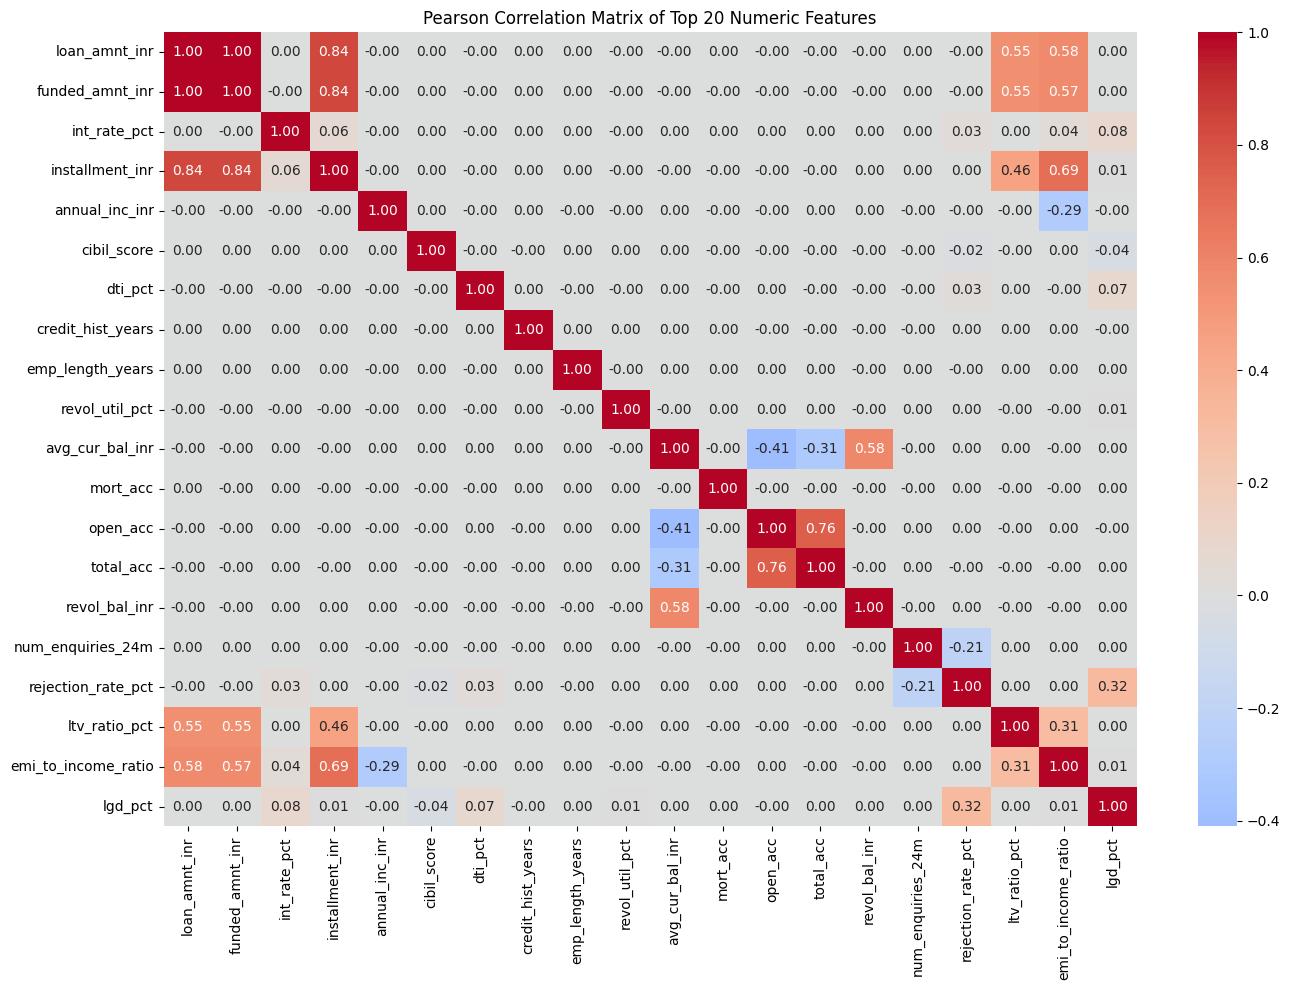

In [142]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title(
    "Pearson Correlation Matrix of Top 20 Numeric Features"
)

plt.tight_layout()
plt.show()

The Pearson correlation matrix reveals several highly correlated predictor pairs. The strongest relationship is between loan_amnt_inr and funded_amnt_inr with a correlation coefficient of 1.00, indicating an almost perfect linear relationship. High correlation among predictors creates multicollinearity in OLS regression, which inflates standard errors, makes coefficient estimates unstable, and reduces the interpretability of individual predictor effects.


##Q2(e)

Create six side-by-side boxplots (int_rate, dti, cibil_score, annual_inc, revol_util, emp_length vs. loan_status). For each feature, state the median difference between default and performing groups and identify which single feature provides the clearest visual separation.

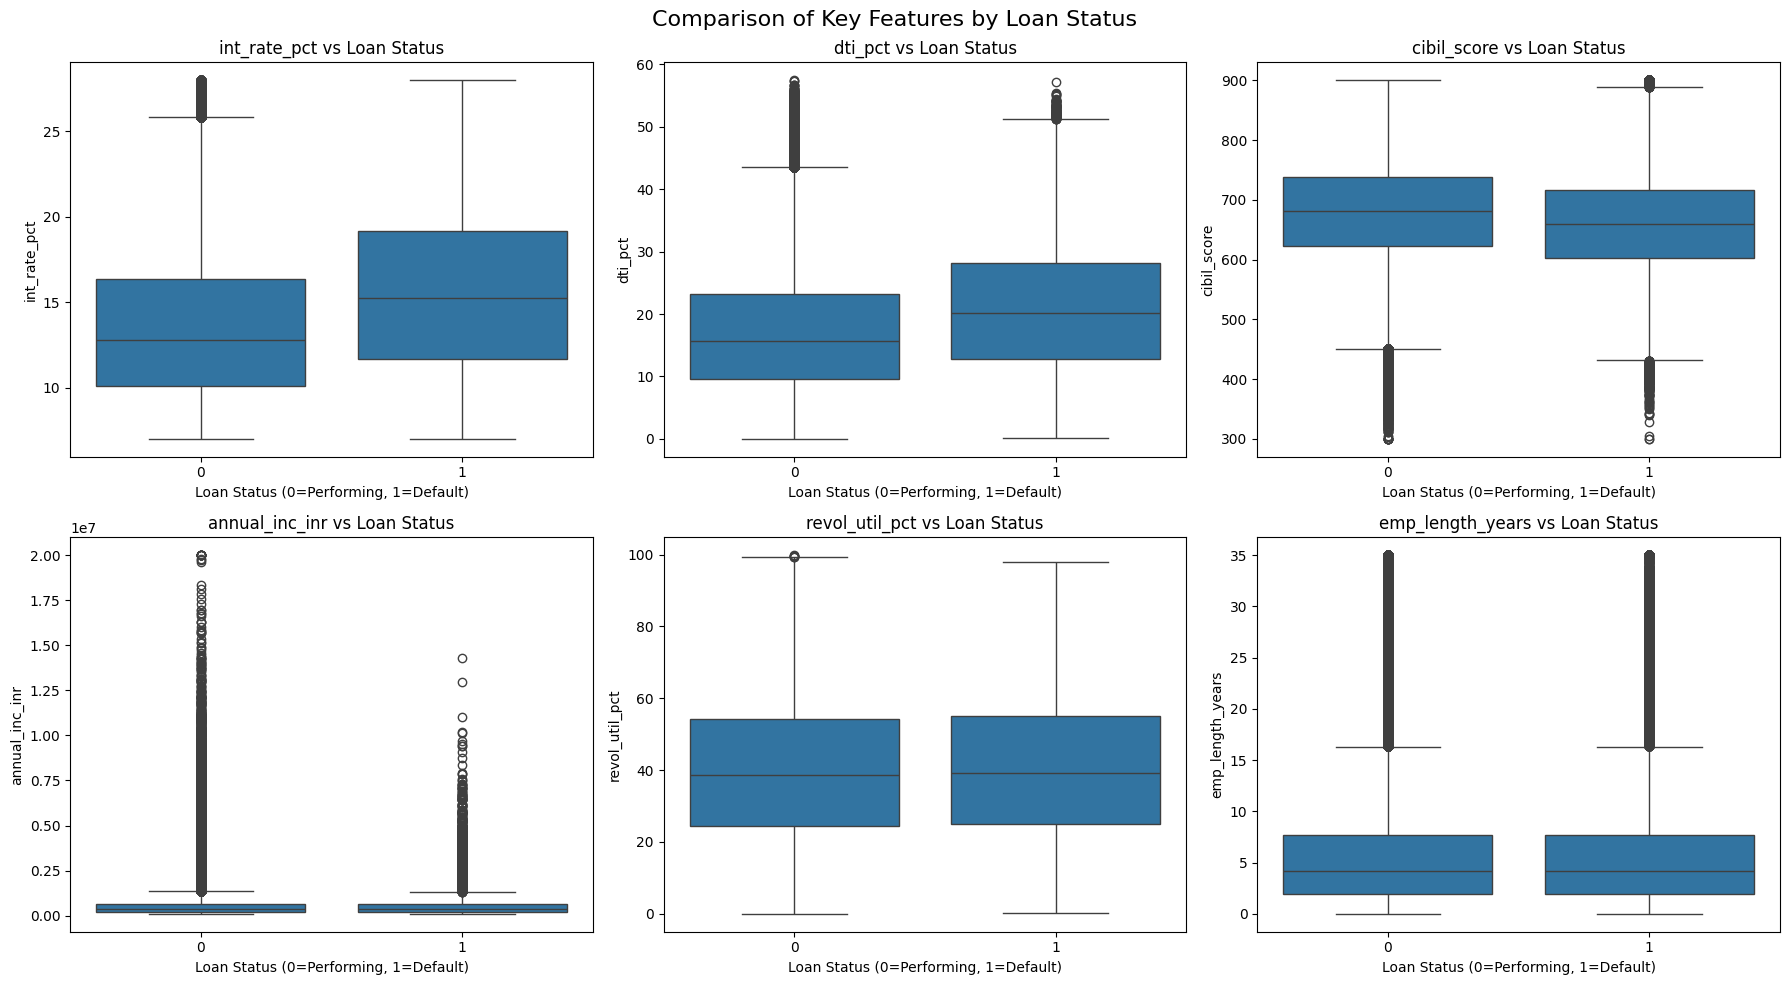

In [146]:
box_cols = [

    "int_rate_pct",
    "dti_pct",
    "cibil_score",
    "annual_inc_inr",
    "revol_util_pct",
    "emp_length_years"

]

fig, axes = plt.subplots(
    2,
    3,
    figsize=(18,10)
)

axes = axes.flatten()

for i, col in enumerate(box_cols):

    sns.boxplot(
        data=master_df,
        x="loan_status",
        y=col,
        ax=axes[i]
    )

    axes[i].set_title(
        f"{col} vs Loan Status"
    )

    axes[i].set_xlabel(
        "Loan Status (0=Performing, 1=Default)"
    )

    axes[i].set_ylabel(col)

plt.suptitle(
    "Comparison of Key Features by Loan Status",
    fontsize=16
)

plt.tight_layout()

plt.show()

In [147]:
median_summary = pd.DataFrame()

for col in box_cols:

    performing_med = (
        master_df.loc[
            master_df["loan_status"] == 0,
            col
        ].median()
    )

    default_med = (
        master_df.loc[
            master_df["loan_status"] == 1,
            col
        ].median()
    )

    median_summary.loc[col, "Performing_Median"] = performing_med

    median_summary.loc[col, "Default_Median"] = default_med

    median_summary.loc[col, "Median_Difference"] = (
        default_med - performing_med
    )

median_summary.round(2)

,Performing_Median,Default_Median,Median_Difference
int_rate_pct,12.78,15.25,2.47
dti_pct,15.72,20.16,4.44
cibil_score,681.00,660.00,-21.00
annual_inc_inr,362424.00,358961.00,-3463.00
revol_util_pct,38.50,39.30,0.80
emp_length_years,4.20,4.20,0.00


The boxplots compare the distributions of six borrower characteristics across performing and defaulted loans. Defaulted borrowers exhibit higher interest rates (+2.47 percentage points median difference), higher debt-to-income ratios (+4.44 percentage points), and lower CIBIL scores (-21 points), indicating weaker credit quality and greater financial stress. Among the six variables, CIBIL score provides the clearest visual separation, suggesting that creditworthiness is one of the strongest indicators of default risk in the portfolio.

##Q2(f)

Plot a grouped bar chart of default rate by loan grade (A through G). Confirm whether the grade system is monotonically ordered. Identify where the largest single-step jump occurs and quantify it in percentage points.

In [148]:
[col for col in master_df.columns if "grade" in col.lower()]

['grade', 'sub_grade']

In [149]:
grade_default = (
    master_df
    .groupby("grade")["loan_status"]
    .mean()
    .mul(100)
    .reset_index()
)

grade_default.columns = [
    "Grade",
    "Default_Rate"
]

grade_default = (
    grade_default
    .sort_values("Grade")
)

grade_default

,Grade,Default_Rate
0,A,2.231201
1,B,2.686735
2,C,3.350654
3,D,4.184456
4,E,5.289755
5,F,6.893610
6,G,8.942513


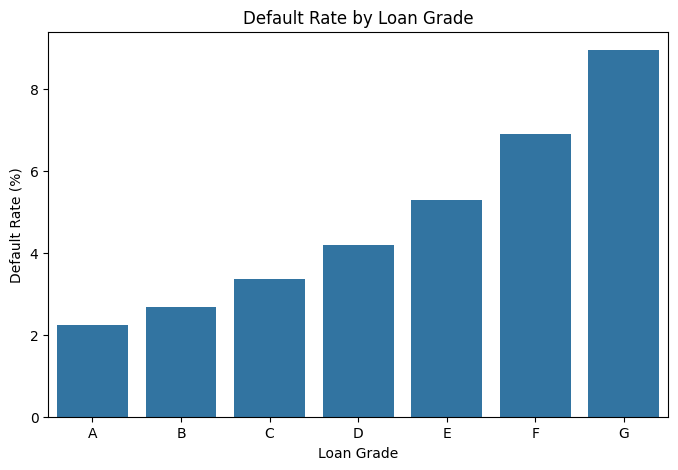

In [150]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    data=grade_default,
    x="Grade",
    y="Default_Rate"
)

plt.title(
    "Default Rate by Loan Grade"
)

plt.xlabel(
    "Loan Grade"
)

plt.ylabel(
    "Default Rate (%)"
)

plt.show()

In [151]:
grade_default["Step_Change"] = (
    grade_default["Default_Rate"]
    .diff()
)

grade_default

,Grade,Default_Rate,Step_Change
0,A,2.231201,NaN
1,B,2.686735,0.455534
2,C,3.350654,0.663918
3,D,4.184456,0.833802
4,E,5.289755,1.105300
5,F,6.893610,1.603855
6,G,8.942513,2.048903


The default rate increases steadily from 2.23% for Grade A loans to 8.94% for Grade G loans, confirming that the grading system is monotonically ordered and effectively differentiates borrower risk levels. The largest increase occurs between Grades F and G, where the default rate rises by 2.05 percentage points, indicating a substantial deterioration in credit quality at the highest-risk segment. From a business perspective, Grade G loans may require stricter underwriting standards, higher pricing, or enhanced monitoring due to their significantly elevated default risk.

##Q2(g)

Calculate the default rate for each loan purpose and display as a horizontal bar chart, sorted descending. Identify the three highest-risk and two lowest-risk loan purposes. Quantify the ratio between the highest and lowest default rates.

In [152]:
purpose_default = (
    master_df
    .groupby("loan_purpose")["loan_status"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .reset_index(name="Default_Rate")
)

purpose_default.head()

,loan_purpose,Default_Rate
0,major_purchase,4.005189
1,car,3.914783
2,small_business,3.911769
3,vacation,3.905544
4,debt_consolidation,3.896907


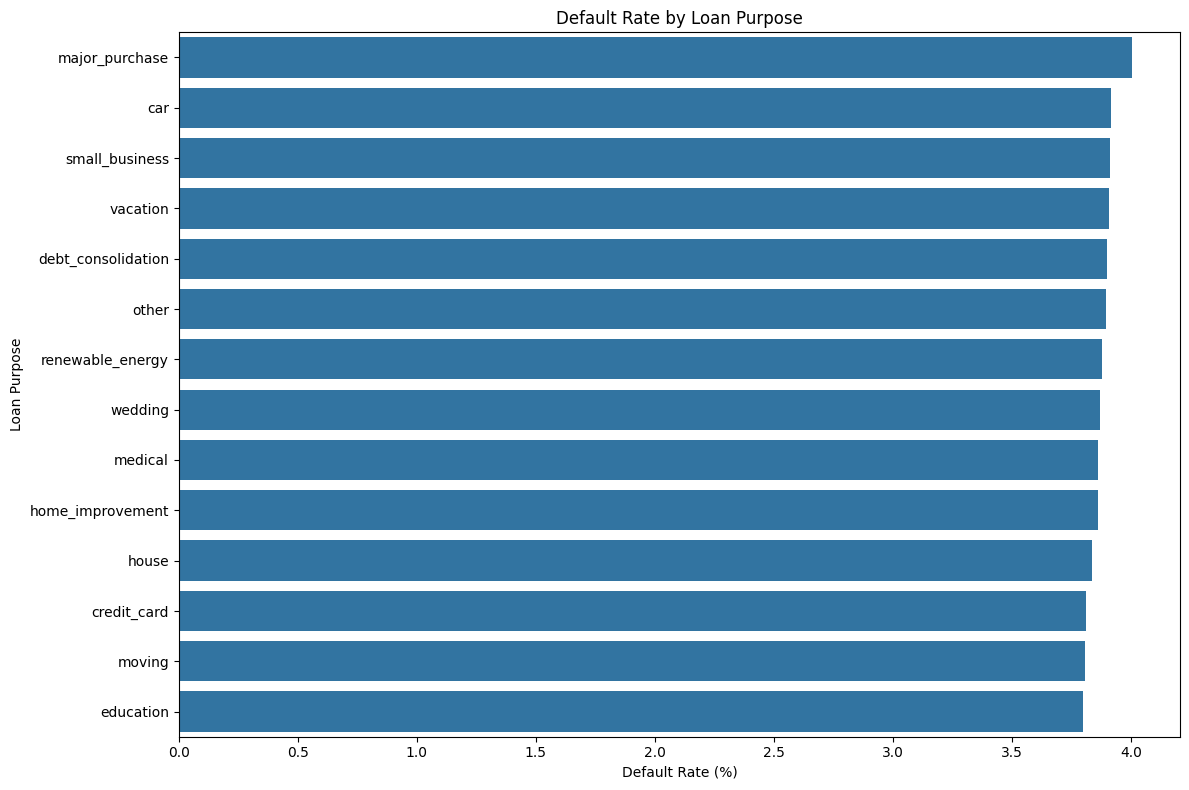

In [153]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))

sns.barplot(
    data=purpose_default,
    y="loan_purpose",
    x="Default_Rate"
)

plt.title("Default Rate by Loan Purpose")
plt.xlabel("Default Rate (%)")
plt.ylabel("Loan Purpose")

plt.tight_layout()
plt.show()

In [154]:
top3 = purpose_default.head(3)
bottom2 = purpose_default.tail(2)

print("Top 3 Highest Risk Purposes")
print(top3)

print("\nBottom 2 Lowest Risk Purposes")
print(bottom2)

Top 3 Highest Risk Purposes
     loan_purpose  Default_Rate
0  major_purchase      4.005189
1             car      3.914783
2  small_business      3.911769

Bottom 2 Lowest Risk Purposes
   loan_purpose  Default_Rate
12       moving      3.804655
13    education      3.799941


In [155]:
highest_rate = purpose_default["Default_Rate"].max()
lowest_rate = purpose_default["Default_Rate"].min()

risk_ratio = highest_rate / lowest_rate

print(f"Highest Default Rate: {highest_rate:.2f}%")
print(f"Lowest Default Rate: {lowest_rate:.2f}%")
print(f"Risk Ratio: {risk_ratio:.2f}:1")

Highest Default Rate: 4.01%
Lowest Default Rate: 3.80%
Risk Ratio: 1.05:1


Risk Ratio = 1.05:1

Default rates vary only slightly across loan purposes, ranging from 3.80% to 4.01%. Major purchase loans have the highest default rate while education loans have the lowest. The small risk ratio of 1.05:1 indicates that loan purpose alone is a weak predictor of default risk and should be combined with stronger variables such as loan grade, CIBIL score, and debt burden.